In [1]:
import os
import time
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

EPOCHS = 5
LEARNING_RATE = 1e-3

SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# ==========================================
# DATASET PATH
# ==========================================

from pathlib import Path

DATASET_PATH = Path(
    "/kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds"
)

MASK_DIR = DATASET_PATH / "Mask"
NO_MASK_DIR = DATASET_PATH / "No_mask"

print("Mask directory:", MASK_DIR)
print("No-mask directory:", NO_MASK_DIR)

Mask directory: /kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds/Mask
No-mask directory: /kaggle/input/datasets/satishchandra9618/face-mask-data/Face_mask_ds/No_mask


In [3]:
# ==========================================
# COLLECT IMAGE PATHS
# ==========================================

mask_paths = list(MASK_DIR.glob("*"))
no_mask_paths = list(NO_MASK_DIR.glob("*"))

print("Mask images   :", len(mask_paths))
print("No-mask images:", len(no_mask_paths))

all_paths = (
    [str(p) for p in no_mask_paths] +
    [str(p) for p in mask_paths]
)

all_labels = (
    [0] * len(no_mask_paths) +
    [1] * len(mask_paths)
)

print("Total images:", len(all_paths))

Mask images   : 18197
No-mask images: 17513
Total images: 35710


In [4]:
# ==========================================
# TRAIN / VALIDATION / TEST SPLIT
# ==========================================

from sklearn.model_selection import train_test_split

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths,
    all_labels,
    test_size=0.20,
    stratify=all_labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    stratify=temp_labels,
    random_state=SEED
)

print("TRAIN      :", len(train_paths))
print("VALIDATION :", len(val_paths))
print("TEST       :", len(test_paths))

TRAIN      : 28568
VALIDATION : 3571
TEST       : 3571


In [5]:
# ==========================================
# CLASS DISTRIBUTION
# ==========================================

def distribution(labels):
    labels = np.array(labels)

    return {
        "No_mask": int(np.sum(labels == 0)),
        "Mask": int(np.sum(labels == 1))
    }

print("TRAIN")
print(distribution(train_labels))

print("\nVALIDATION")
print(distribution(val_labels))

print("\nTEST")
print(distribution(test_labels))

TRAIN
{'No_mask': 14010, 'Mask': 14558}

VALIDATION
{'No_mask': 1751, 'Mask': 1820}

TEST
{'No_mask': 1752, 'Mask': 1819}


In [6]:
# ==========================================
# RESNET50 PREPROCESSING
# ==========================================

def load_image_resnet(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=3,
        expand_animations=False
    )

    image.set_shape([None, None, 3])

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    image = tf.keras.applications.resnet50.preprocess_input(
        image
    )

    return image, tf.cast(label, tf.float32)

print("ResNet50 preprocessing ready!")

ResNet50 preprocessing ready!


In [7]:
# ==========================================
# CREATE DATASETS
# ==========================================

train_ds = tf.data.Dataset.from_tensor_slices(
    (train_paths, train_labels)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (val_paths, val_labels)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (test_paths, test_labels)
)


train_ds = (
    train_ds
    .shuffle(
        10000,
        seed=SEED
    )
    .map(
        load_image_resnet,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


val_ds = (
    val_ds
    .map(
        load_image_resnet,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


test_ds = (
    test_ds
    .map(
        load_image_resnet,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("Datasets ready!")

I0000 00:00:1789807150.609034      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789807150.611972      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Datasets ready!


# Baseline Transfer Learning

In [9]:
# ==========================================
# E5: FROZEN RESNET50
# ==========================================

base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

e5_model = tf.keras.Model(
    inputs,
    outputs
)

e5_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

e5_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 262,401 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [10]:
# ==========================================
# E5 TRAINING
# ==========================================

start = time.time()

history_e5 = e5_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

e5_time = (time.time() - start) / 60

print(f"\nE5 training time: {e5_time:.2f} minutes")

Epoch 1/5
  2/893 ━━━━━━━━━━━━━━━━━━━━ 1:18 88ms/step - accuracy: 0.5391 - loss: 1.0648  

I0000 00:00:1789807239.328361     144 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


893/893 ━━━━━━━━━━━━━━━━━━━━ 186s 194ms/step - accuracy: 0.9955 - loss: 0.0139 - val_accuracy: 0.9986 - val_loss: 0.0078
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 106s 119ms/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9994 - val_loss: 0.0040
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 105s 118ms/step - accuracy: 0.9992 - loss: 0.0030 - val_accuracy: 0.9992 - val_loss: 0.0068
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 105s 117ms/step - accuracy: 0.9997 - loss: 0.0011 - val_accuracy: 0.9994 - val_loss: 0.0047
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 104s 116ms/step - accuracy: 0.9989 - loss: 0.0049 - val_accuracy: 0.9994 - val_loss: 0.0046

E5 training time: 10.11 minutes


In [11]:
# ==========================================
# E5 EVALUATION
# ==========================================

y_true = np.array(test_labels).astype(int)

y_prob = e5_model.predict(
    test_ds,
    verbose=0
).reshape(-1)

y_pred = (
    y_prob >= 0.5
).astype(int)

e5_accuracy = accuracy_score(
    y_true,
    y_pred
)

e5_precision = precision_score(
    y_true,
    y_pred
)

e5_recall = recall_score(
    y_true,
    y_pred
)

e5_f1 = f1_score(
    y_true,
    y_pred
)

e5_auc = roc_auc_score(
    y_true,
    y_prob
)

print("=" * 40)
print("E5 RESULTS")
print("=" * 40)

print(f"Accuracy  : {e5_accuracy:.4f}")
print(f"Precision : {e5_precision:.4f}")
print(f"Recall    : {e5_recall:.4f}")
print(f"F1-Score  : {e5_f1:.4f}")
print(f"ROC-AUC   : {e5_auc:.4f}")

E5 RESULTS
Accuracy  : 0.9997
Precision : 0.9995
Recall    : 1.0000
F1-Score  : 0.9997
ROC-AUC   : 1.0000


In [12]:
# ==========================================
# E5 CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_true,
    y_pred
)

print("E5 Confusion Matrix:")
print(cm)

print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "No_mask",
            "Mask"
        ]
    )
)

E5 Confusion Matrix:
[[1751    1]
 [   0 1819]]

Classification Report:
              precision    recall  f1-score   support

     No_mask       1.00      1.00      1.00      1752
        Mask       1.00      1.00      1.00      1819

    accuracy                           1.00      3571
   macro avg       1.00      1.00      1.00      3571
weighted avg       1.00      1.00      1.00      3571



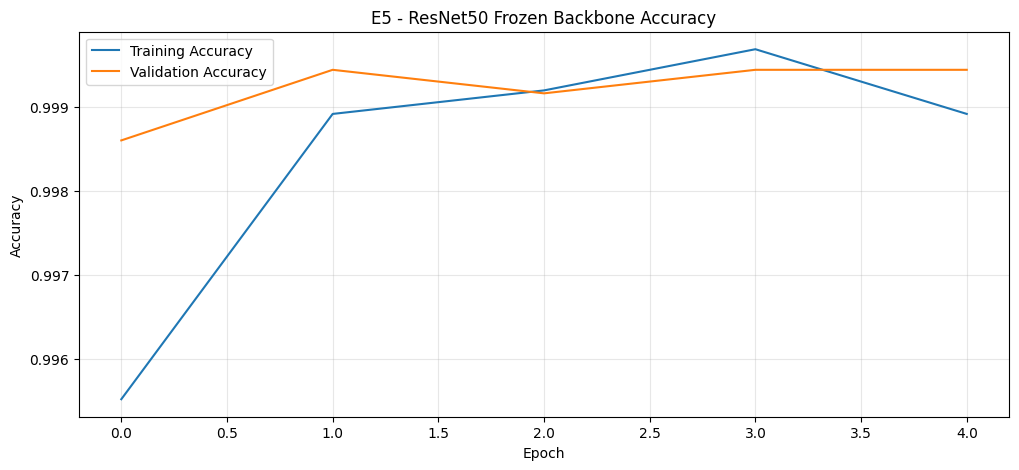

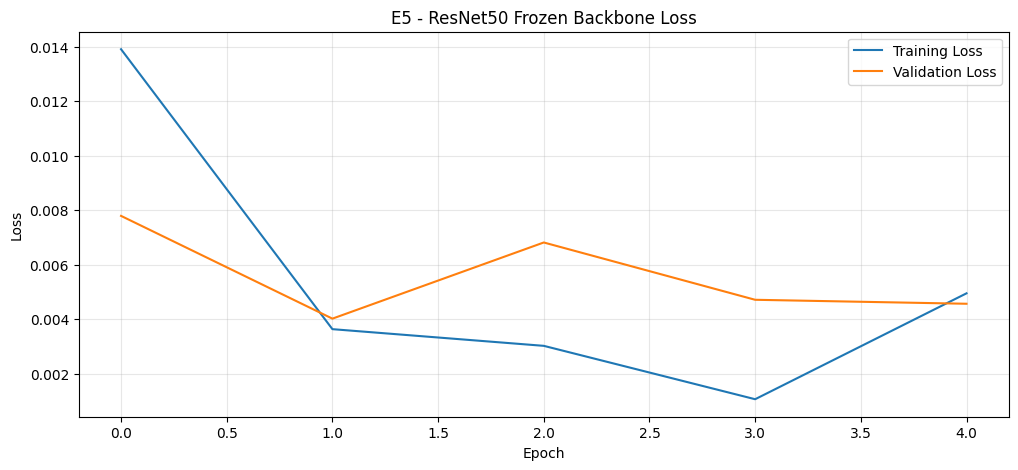

In [13]:
# ==========================================
# E5 TRAINING CURVES
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    history_e5.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_e5.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "E5 - ResNet50 Frozen Backbone Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(12, 5))

plt.plot(
    history_e5.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_e5.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "E5 - ResNet50 Frozen Backbone Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ResNet50 + Data Augmentation

In [14]:
# ==========================================
# E6: DATA AUGMENTATION
# ==========================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.05
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )
])

print("E6 augmentation pipeline ready!")

E6 augmentation pipeline ready!


In [15]:
# ==========================================
# E6 AUGMENTED TRAINING DATASET
# ==========================================

def load_image_resnet_augmented(path, label):

    image, label = load_image_resnet(
        path,
        label
    )

    image = data_augmentation(
        image,
        training=True
    )

    return image, label


train_ds_e6 = (
    tf.data.Dataset
    .from_tensor_slices(
        (train_paths, train_labels)
    )
    .shuffle(
        10000,
        seed=SEED
    )
    .map(
        load_image_resnet_augmented,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("E6 training dataset ready!")

E6 training dataset ready!


In [16]:
# ==========================================
# E6 RESNET50 + AUGMENTATION
# ==========================================

base_model_e6 = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_e6.trainable = False

inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model_e6(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(
    0.3
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

e6_model = tf.keras.Model(
    inputs,
    outputs
)

e6_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("E6 model ready!")

E6 model ready!


In [19]:
# ==========================================
# E6 TRAINING
# ==========================================

start = time.time()

history_e6 = e6_model.fit(
    train_ds_e6,
    validation_data=val_ds,
    epochs=5
)

e6_time = (time.time() - start) / 60

print(
    f"\nE6 training time: {e6_time:.2f} minutes"
)

Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 277s 310ms/step - accuracy: 0.9981 - loss: 0.0054 - val_accuracy: 0.9975 - val_loss: 0.0101
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 275s 308ms/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9972 - val_loss: 0.0143
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 274s 307ms/step - accuracy: 0.9980 - loss: 0.0063 - val_accuracy: 0.9871 - val_loss: 0.0392
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 274s 306ms/step - accuracy: 0.9977 - loss: 0.0083 - val_accuracy: 0.9986 - val_loss: 0.0084
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 275s 308ms/step - accuracy: 0.9985 - loss: 0.0052 - val_accuracy: 0.9966 - val_loss: 0.0108

E6 training time: 22.93 minutes


In [20]:

# ==========================================
# E6 EVALUATION
# ==========================================

y_true = np.array(test_labels).astype(int)

y_prob_e6 = e6_model.predict(
    test_ds,
    verbose=0
).reshape(-1)

y_pred_e6 = (
    y_prob_e6 >= 0.5
).astype(int)

e6_accuracy = accuracy_score(
    y_true,
    y_pred_e6
)

e6_precision = precision_score(
    y_true,
    y_pred_e6
)

e6_recall = recall_score(
    y_true,
    y_pred_e6
)

e6_f1 = f1_score(
    y_true,
    y_pred_e6
)

e6_auc = roc_auc_score(
    y_true,
    y_prob_e6
)

print("=" * 40)
print("E6 RESULTS")
print("=" * 40)

print(f"Accuracy  : {e6_accuracy:.4f}")
print(f"Precision : {e6_precision:.4f}")
print(f"Recall    : {e6_recall:.4f}")
print(f"F1-score  : {e6_f1:.4f}")
print(f"ROC-AUC   : {e6_auc:.4f}")

E6 RESULTS
Accuracy  : 0.9952
Precision : 1.0000
Recall    : 0.9907
F1-score  : 0.9953
ROC-AUC   : 1.0000


In [21]:
# ==========================================
# E6 CONFUSION MATRIX
# ==========================================

cm_e6 = confusion_matrix(
    y_true,
    y_pred_e6
)

print("\nE6 Confusion Matrix:")
print(cm_e6)

print("\nE6 Classification Report:")

print(
    classification_report(
        y_true,
        y_pred_e6,
        target_names=[
            "No_mask",
            "Mask"
        ]
    )
)


E6 Confusion Matrix:
[[1752    0]
 [  17 1802]]

E6 Classification Report:
              precision    recall  f1-score   support

     No_mask       0.99      1.00      1.00      1752
        Mask       1.00      0.99      1.00      1819

    accuracy                           1.00      3571
   macro avg       1.00      1.00      1.00      3571
weighted avg       1.00      1.00      1.00      3571



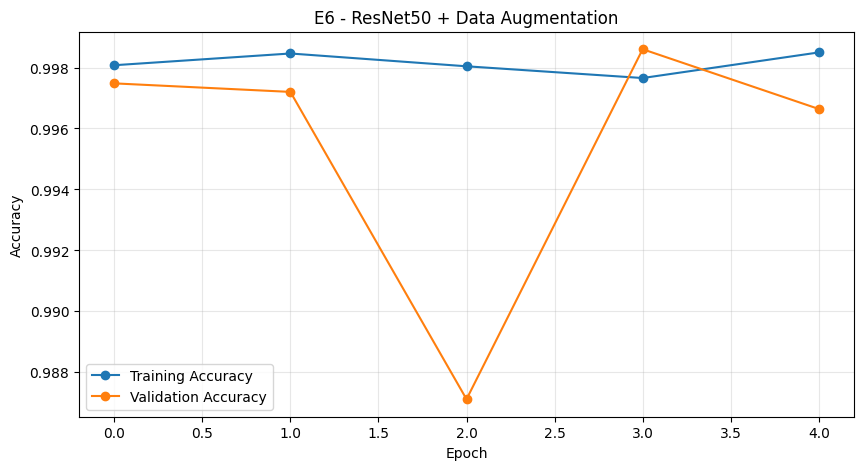

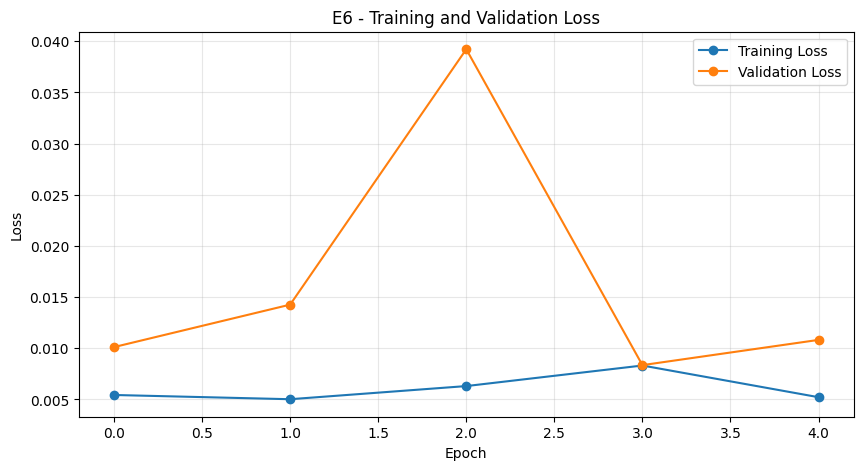

In [22]:
# ==========================================
# E6 TRAINING CURVES
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_e6.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_e6.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "E6 - ResNet50 + Data Augmentation"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history_e6.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_e6.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "E6 - Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# ResNet50 Fine-Tuning

In [23]:
# ==========================================
# E7: RESNET50 FINE-TUNING
# ==========================================

base_model_e7 = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze most of the backbone
base_model_e7.trainable = True

# Freeze the earlier layers
for layer in base_model_e7.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model_e7.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model_e7(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu"
)(x)

x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(x)

e7_model = tf.keras.Model(
    inputs,
    outputs
)

e7_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("E7 model ready!")

print(
    "Trainable layers:",
    sum(
        layer.trainable
        for layer in e7_model.layers
    )
)

E7 model ready!
Trainable layers: 6


In [24]:
# ==========================================
# E7 TRAINING
# ==========================================

start = time.time()

history_e7 = e7_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

e7_time = (time.time() - start) / 60

print(
    f"\nE7 training time: {e7_time:.2f} minutes"
)

Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 163s 165ms/step - accuracy: 0.9926 - loss: 0.0190 - val_accuracy: 0.9994 - val_loss: 0.0022
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 137s 153ms/step - accuracy: 0.9996 - loss: 0.0012 - val_accuracy: 0.9997 - val_loss: 0.0037
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 133s 149ms/step - accuracy: 1.0000 - loss: 1.2744e-04 - val_accuracy: 0.9997 - val_loss: 0.0041
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 133s 149ms/step - accuracy: 1.0000 - loss: 6.7421e-06 - val_accuracy: 0.9997 - val_loss: 0.0046
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 132s 148ms/step - accuracy: 1.0000 - loss: 4.5466e-06 - val_accuracy: 0.9997 - val_loss: 0.0048

E7 training time: 11.64 minutes


In [25]:
# ==========================================
# E7 EVALUATION
# ==========================================

y_true = np.array(test_labels).astype(int)

y_prob_e7 = e7_model.predict(
    test_ds,
    verbose=0
).reshape(-1)

y_pred_e7 = (
    y_prob_e7 >= 0.5
).astype(int)

e7_accuracy = accuracy_score(
    y_true,
    y_pred_e7
)

e7_precision = precision_score(
    y_true,
    y_pred_e7
)

e7_recall = recall_score(
    y_true,
    y_pred_e7
)

e7_f1 = f1_score(
    y_true,
    y_pred_e7
)

e7_auc = roc_auc_score(
    y_true,
    y_prob_e7
)

print("=" * 40)
print("E7 RESULTS")
print("=" * 40)

print(f"Accuracy  : {e7_accuracy:.4f}")
print(f"Precision : {e7_precision:.4f}")
print(f"Recall    : {e7_recall:.4f}")
print(f"F1-score  : {e7_f1:.4f}")
print(f"ROC-AUC   : {e7_auc:.4f}")

E7 RESULTS
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-score  : 1.0000
ROC-AUC   : 1.0000


In [26]:
# ==========================================
# E7 CONFUSION MATRIX
# ==========================================

cm_e7 = confusion_matrix(
    y_true,
    y_pred_e7
)

print("E7 Confusion Matrix:")
print(cm_e7)

print("\nE7 Classification Report:")

print(
    classification_report(
        y_true,
        y_pred_e7,
        target_names=[
            "No_mask",
            "Mask"
        ]
    )
)

E7 Confusion Matrix:
[[1752    0]
 [   0 1819]]

E7 Classification Report:
              precision    recall  f1-score   support

     No_mask       1.00      1.00      1.00      1752
        Mask       1.00      1.00      1.00      1819

    accuracy                           1.00      3571
   macro avg       1.00      1.00      1.00      3571
weighted avg       1.00      1.00      1.00      3571



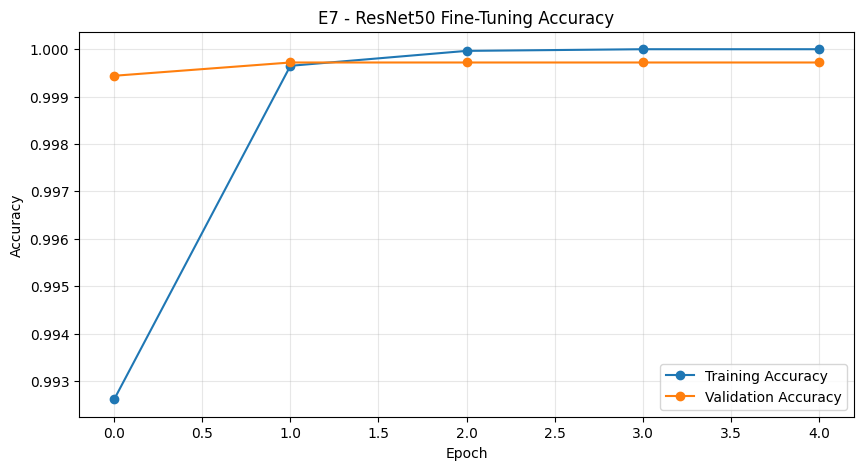

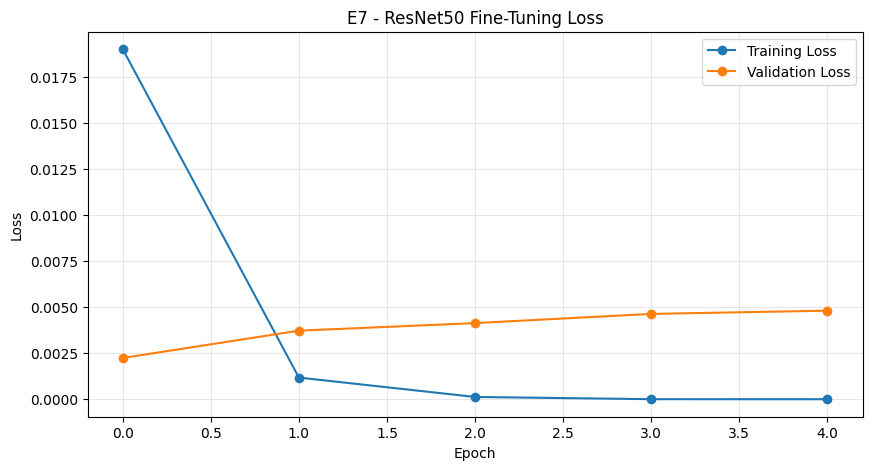

In [27]:
# ==========================================
# E7 TRAINING CURVES
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_e7.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_e7.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "E7 - ResNet50 Fine-Tuning Accuracy"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history_e7.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_e7.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "E7 - ResNet50 Fine-Tuning Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

# fine-tuning + augmentation + regularization

In [28]:
# ==========================================
# E8: AUGMENTATION + REGULARIZATION
# ==========================================

data_augmentation_e8 = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomContrast(0.10)
])

print("E8 augmentation ready!")

E8 augmentation ready!


In [29]:
# ==========================================
# E8 TRAINING DATASET
# ==========================================

def load_image_resnet_e8(path, label):

    image, label = load_image_resnet(
        path,
        label
    )

    image = data_augmentation_e8(
        image,
        training=True
    )

    return image, label


train_ds_e8 = (
    tf.data.Dataset
    .from_tensor_slices(
        (train_paths, train_labels)
    )
    .shuffle(
        10000,
        seed=SEED
    )
    .map(
        load_image_resnet_e8,
        num_parallel_calls=AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("E8 training dataset ready!")

E8 training dataset ready!


In [30]:
# ==========================================
# E8 RESNET50
# FINE-TUNING + REGULARIZATION
# ==========================================

base_model_e8 = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model_e8.trainable = True

# Freeze earlier layers
for layer in base_model_e8.layers[:-30]:
    layer.trainable = False

# Keep BatchNorm frozen
for layer in base_model_e8.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False


inputs = tf.keras.Input(
    shape=(224, 224, 3)
)

x = base_model_e8(
    inputs,
    training=False
)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(
    128,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = tf.keras.layers.Dropout(
    0.5
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

e8_model = tf.keras.Model(
    inputs,
    outputs
)

e8_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("E8 model ready!")

E8 model ready!


In [31]:
# ==========================================
# E8 TRAINING
# ==========================================

start = time.time()

history_e8 = e8_model.fit(
    train_ds_e8,
    validation_data=val_ds,
    epochs=5
)

e8_time = (time.time() - start) / 60

print(
    f"\nE8 training time: {e8_time:.2f} minutes"
)

Epoch 1/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 327s 351ms/step - accuracy: 0.9805 - loss: 0.0720 - val_accuracy: 0.9936 - val_loss: 0.0416
Epoch 2/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 303s 339ms/step - accuracy: 0.9980 - loss: 0.0309 - val_accuracy: 0.9964 - val_loss: 0.0345
Epoch 3/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 302s 339ms/step - accuracy: 0.9982 - loss: 0.0292 - val_accuracy: 0.9989 - val_loss: 0.0316
Epoch 4/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 303s 339ms/step - accuracy: 0.9989 - loss: 0.0275 - val_accuracy: 0.9924 - val_loss: 0.0435
Epoch 5/5
893/893 ━━━━━━━━━━━━━━━━━━━━ 304s 340ms/step - accuracy: 0.9988 - loss: 0.0271 - val_accuracy: 0.9994 - val_loss: 0.0267

E8 training time: 25.66 minutes


In [32]:
# ==========================================
# E8 EVALUATION
# ==========================================

y_true = np.array(test_labels).astype(int)

y_prob_e8 = e8_model.predict(
    test_ds,
    verbose=0
).reshape(-1)

y_pred_e8 = (
    y_prob_e8 >= 0.5
).astype(int)

e8_accuracy = accuracy_score(
    y_true,
    y_pred_e8
)

e8_precision = precision_score(
    y_true,
    y_pred_e8
)

e8_recall = recall_score(
    y_true,
    y_pred_e8
)

e8_f1 = f1_score(
    y_true,
    y_pred_e8
)

e8_auc = roc_auc_score(
    y_true,
    y_prob_e8
)

print("=" * 40)
print("E8 RESULTS")
print("=" * 40)

print(f"Accuracy  : {e8_accuracy:.4f}")
print(f"Precision : {e8_precision:.4f}")
print(f"Recall    : {e8_recall:.4f}")
print(f"F1-score  : {e8_f1:.4f}")
print(f"ROC-AUC   : {e8_auc:.4f}")

E8 RESULTS
Accuracy  : 0.9989
Precision : 0.9994
Recall    : 0.9984
F1-score  : 0.9989
ROC-AUC   : 0.9999


In [33]:
# ==========================================
# E8 CONFUSION MATRIX
# ==========================================

cm_e8 = confusion_matrix(
    y_true,
    y_pred_e8
)

print("E8 Confusion Matrix:")
print(cm_e8)

print("\nE8 Classification Report:")

print(
    classification_report(
        y_true,
        y_pred_e8,
        target_names=[
            "No_mask",
            "Mask"
        ]
    )
)

E8 Confusion Matrix:
[[1751    1]
 [   3 1816]]

E8 Classification Report:
              precision    recall  f1-score   support

     No_mask       1.00      1.00      1.00      1752
        Mask       1.00      1.00      1.00      1819

    accuracy                           1.00      3571
   macro avg       1.00      1.00      1.00      3571
weighted avg       1.00      1.00      1.00      3571



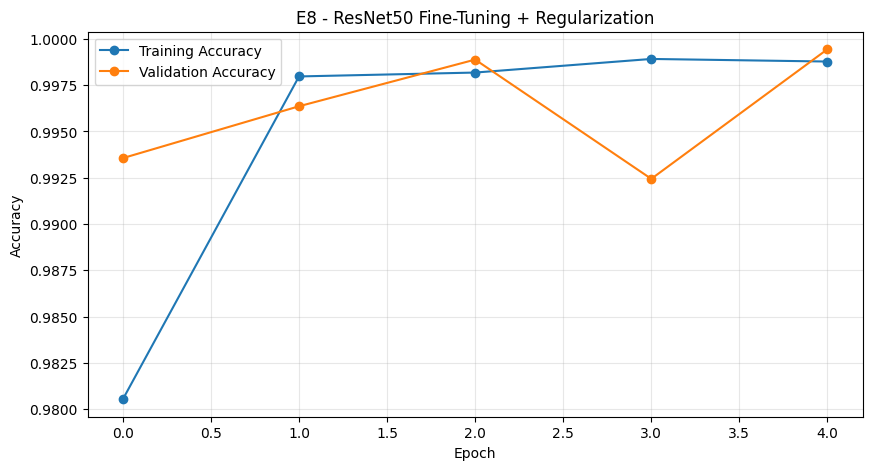

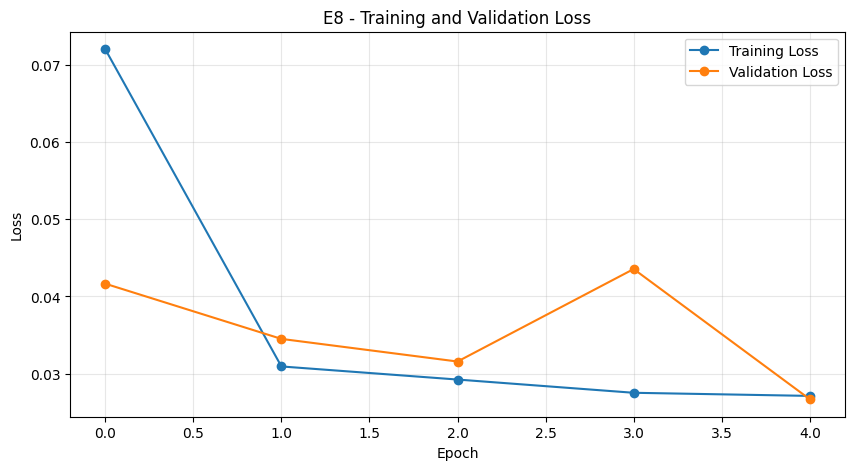

In [34]:
# ==========================================
# E8 TRAINING CURVES
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    history_e8.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history_e8.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "E8 - ResNet50 Fine-Tuning + Regularization"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


plt.figure(figsize=(10, 5))

plt.plot(
    history_e8.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history_e8.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "E8 - Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [35]:
# ==========================================
# E1-E8 FINAL RESULTS
# ==========================================

final_results = pd.DataFrame([
    
    # Custom CNN experiments
    ["E1", "Custom CNN", 
     97.76, 99.77, 95.82, 97.76, 99.89],

    ["E2", "Custom CNN + Augmentation",
     99.24, 98.75, 99.78, 99.26, 99.98],

    ["E3", "Custom CNN + Regularization",
     99.41, 99.83, 99.01, 99.42, 99.97],

    ["E4", "Custom CNN + Augmentation + Regularization",
     99.02, 99.78, 98.30, 99.03, 99.94],

    # ResNet50 transfer-learning experiments
    ["E5", "ResNet50 Frozen",
     e5_accuracy * 100,
     e5_precision * 100,
     e5_recall * 100,
     e5_f1 * 100,
     e5_auc * 100],

    ["E6", "ResNet50 + Augmentation",
     e6_accuracy * 100,
     e6_precision * 100,
     e6_recall * 100,
     e6_f1 * 100,
     e6_auc * 100],

    ["E7", "ResNet50 Fine-Tuning",
     e7_accuracy * 100,
     e7_precision * 100,
     e7_recall * 100,
     e7_f1 * 100,
     e7_auc * 100],

    ["E8", "ResNet50 Fine-Tuning + Regularization",
     e8_accuracy * 100,
     e8_precision * 100,
     e8_recall * 100,
     e8_f1 * 100,
     e8_auc * 100]
    
], columns=[
    "Experiment",
    "Configuration",
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)",
    "ROC-AUC (%)"
])

print("=" * 100)
print("FINAL EXPERIMENT COMPARISON")
print("=" * 100)

display(
    final_results.style
    .format({
        "Accuracy (%)": "{:.2f}",
        "Precision (%)": "{:.2f}",
        "Recall (%)": "{:.2f}",
        "F1-Score (%)": "{:.2f}",
        "ROC-AUC (%)": "{:.2f}"
    })
)

FINAL EXPERIMENT COMPARISON


,Experiment,Configuration,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC (%)
0,E1,Custom CNN,97.76,99.77,95.82,97.76,99.89
1,E2,Custom CNN + Augmentation,99.24,98.75,99.78,99.26,99.98
2,E3,Custom CNN + Regularization,99.41,99.83,99.01,99.42,99.97
3,E4,Custom CNN + Augmentation + Regularization,99.02,99.78,98.30,99.03,99.94
4,E5,ResNet50 Frozen,99.97,99.95,100.00,99.97,100.00
5,E6,ResNet50 + Augmentation,99.52,100.00,99.07,99.53,100.00
6,E7,ResNet50 Fine-Tuning,100.00,100.00,100.00,100.00,100.00
7,E8,ResNet50 Fine-Tuning + Regularization,99.89,99.94,99.84,99.89,99.99


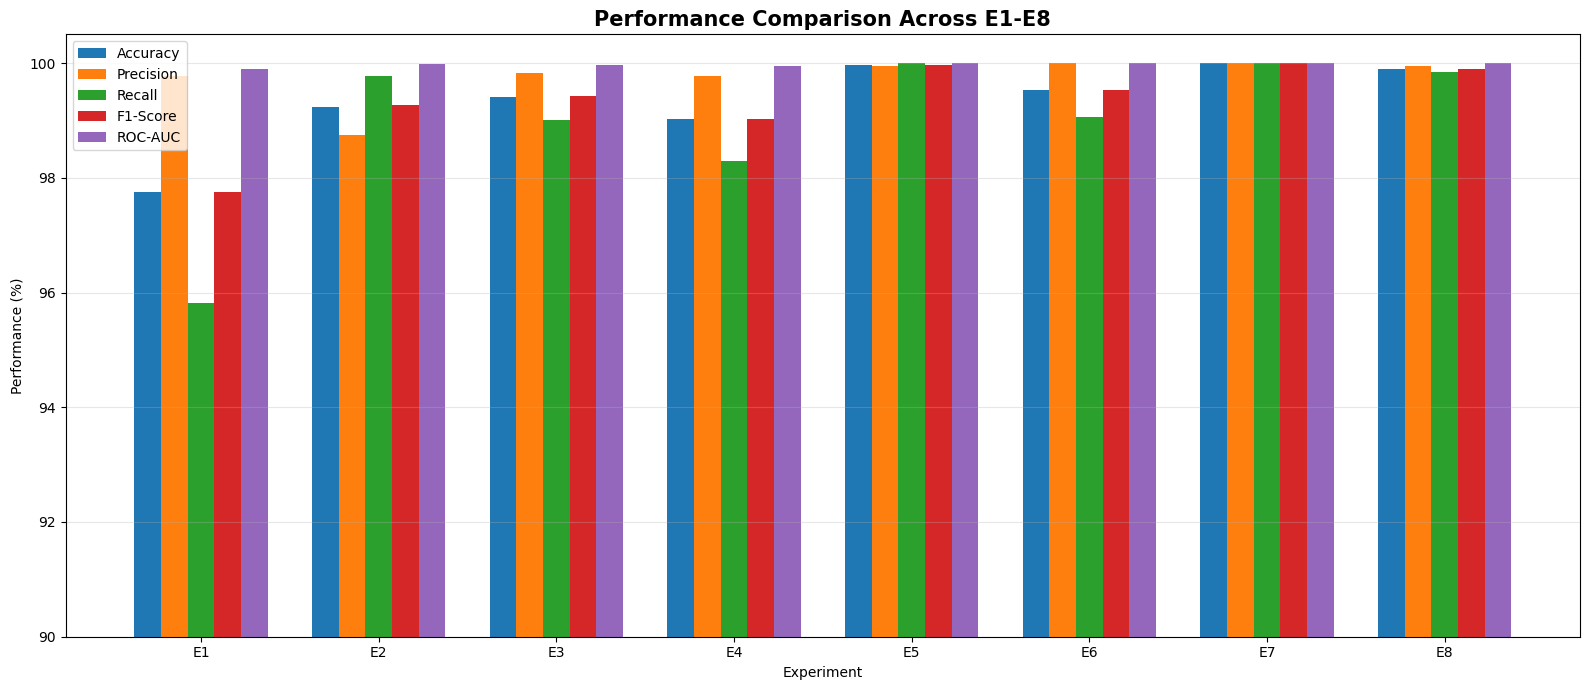

In [36]:
# ==========================================
# E1-E8 PERFORMANCE COMPARISON
# ==========================================

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-Score (%)",
    "ROC-AUC (%)"
]

x = np.arange(len(final_results))
width = 0.15

plt.figure(figsize=(16, 7))

for i, metric in enumerate(metrics):

    plt.bar(
        x + (i - 2) * width,
        final_results[metric],
        width,
        label=metric.replace(" (%)", "")
    )

plt.xticks(
    x,
    final_results["Experiment"]
)

plt.xlabel("Experiment")
plt.ylabel("Performance (%)")

plt.title(
    "Performance Comparison Across E1-E8",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(90, 100.5)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

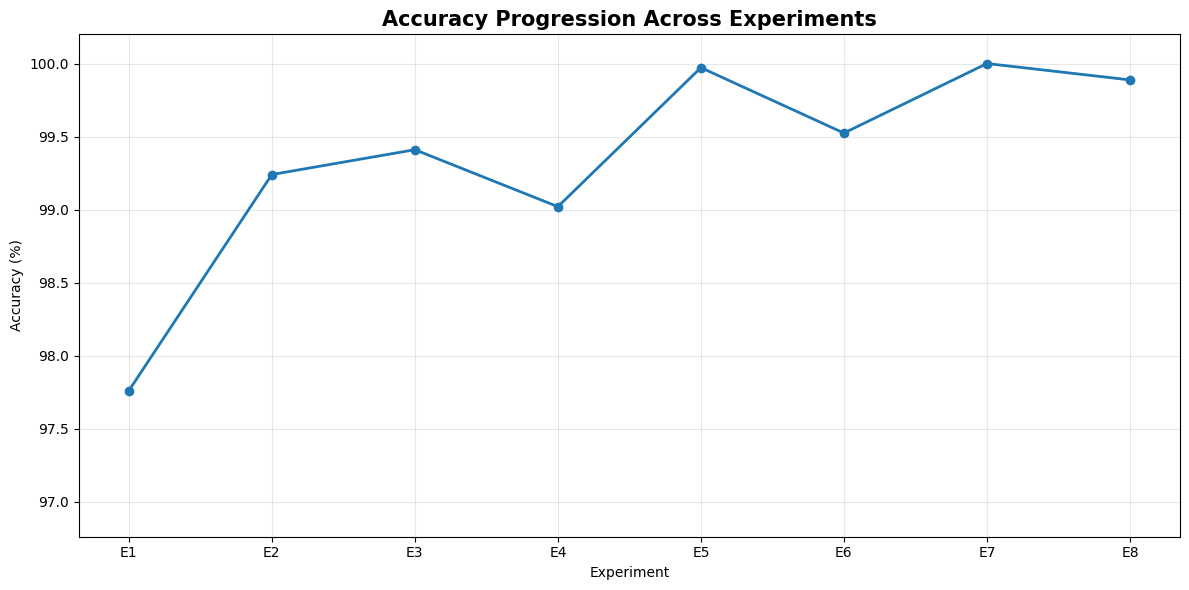

In [37]:
# ==========================================
# ACCURACY PROGRESSION
# ==========================================

plt.figure(figsize=(12, 6))

plt.plot(
    final_results["Experiment"],
    final_results["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.xlabel("Experiment")
plt.ylabel("Accuracy (%)")

plt.title(
    "Accuracy Progression Across Experiments",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(
    final_results["Accuracy (%)"].min() - 1,
    100.2
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# TESTING ON IMAGES ON WEB

In [43]:
from IPython.display import display
from ipywidgets import FileUpload

upload = FileUpload(
    accept="image/*",
    multiple=True
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload', multiple=True)

EXTERNAL IMAGE TEST

Image 1
------------------------------
Prediction : No Mask
Mask probability : 0.0000


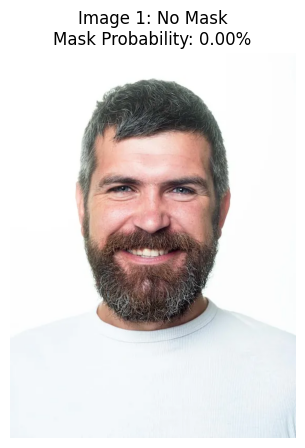


Image 2
------------------------------
Prediction : Mask
Mask probability : 0.9989


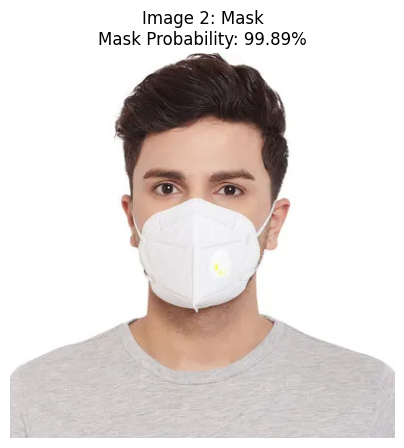


Image 3
------------------------------
Prediction : No Mask
Mask probability : 0.0000


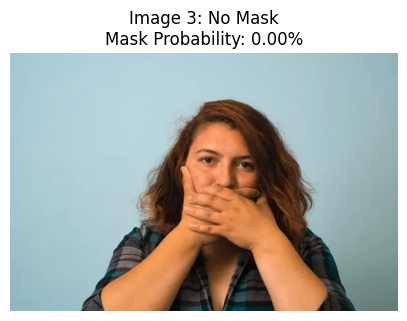

In [44]:
from PIL import Image
import io
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print("=" * 50)
print("EXTERNAL IMAGE TEST")
print("=" * 50)

for i, uploaded_file in enumerate(upload.value):

    image = Image.open(
        io.BytesIO(uploaded_file["content"])
    ).convert("RGB")

    # Resize
    image_resized = image.resize((224, 224))

    # Convert to NumPy
    img_array = np.array(
        image_resized
    ).astype(np.float32)

    # ResNet50 preprocessing
    img_array = tf.keras.applications.resnet50.preprocess_input(
        img_array
    )

    # Add batch dimension
    img_array = np.expand_dims(
        img_array,
        axis=0
    )

    # Prediction
    probability = e8_model.predict(
        img_array,
        verbose=0
    )[0][0]

    prediction = (
        "Mask"
        if probability >= 0.5
        else "No Mask"
    )

    print(f"\nImage {i + 1}")
    print("-" * 30)
    print("Prediction :", prediction)
    print(f"Mask probability : {probability:.4f}")

    # Display
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Image {i+1}: {prediction}\n"
        f"Mask Probability: {probability:.2%}"
    )
    plt.show()